In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("C:\\Users\\bingi\\Downloads\\car_prices.csv\\car_prices.csv")
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [4]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 558837
Number of columns: 16


In [6]:
df.nunique()

year                34
make                96
model              973
trim              1963
body                87
transmission         4
vin             550297
state               64
condition           41
odometer        172278
color               46
interior            17
seller           14263
mmr               1101
sellingprice      1887
saledate          3766
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.isnull().sum().sort_values(ascending = False)

transmission    65352
body            13195
condition       11820
trim            10651
model           10399
make            10301
color             749
interior          749
odometer           94
mmr                38
saledate           12
sellingprice       12
vin                 4
year                0
state               0
seller              0
dtype: int64

In [9]:
df = df.dropna(subset=['sellingprice', 'year', 'make', 'saledate', 'transmission', 'body'])

df['sellingprice'] = pd.to_numeric(df['sellingprice'], errors='coerce')
df['odometer'] = pd.to_numeric(df['odometer'], errors='coerce')
df['condition'] = pd.to_numeric(df['condition'], errors='coerce')

df.loc[df['condition'] > 5, 'condition'] = df.loc[df['condition'] > 5, 'condition'] / 10

df['saledate'] = pd.to_datetime(df['saledate'].astype(str).str.split(' GMT').str[0], errors='coerce')



df['body'] = df['body'].astype(str).str.lower()

df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['condition'] = df['condition'].fillna(df['condition'].median())

df = df.dropna(subset=['sellingprice'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 482442 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   year          482442 non-null  int64         
 1   make          482442 non-null  object        
 2   model         482350 non-null  object        
 3   trim          482442 non-null  object        
 4   body          482442 non-null  object        
 5   transmission  482442 non-null  object        
 6   vin           482438 non-null  object        
 7   state         482442 non-null  object        
 8   condition     482442 non-null  float64       
 9   odometer      482442 non-null  float64       
 10  color         481861 non-null  object        
 11  interior      481861 non-null  object        
 12  seller        482442 non-null  object        
 13  mmr           482416 non-null  float64       
 14  sellingprice  482442 non-null  float64       
 15  saledate      482416 n

C:\Users\bingi\AppData\Local\Temp\ipykernel_4712\3110487134.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_makes.values, y=top_10_makes.index, palette='magma')


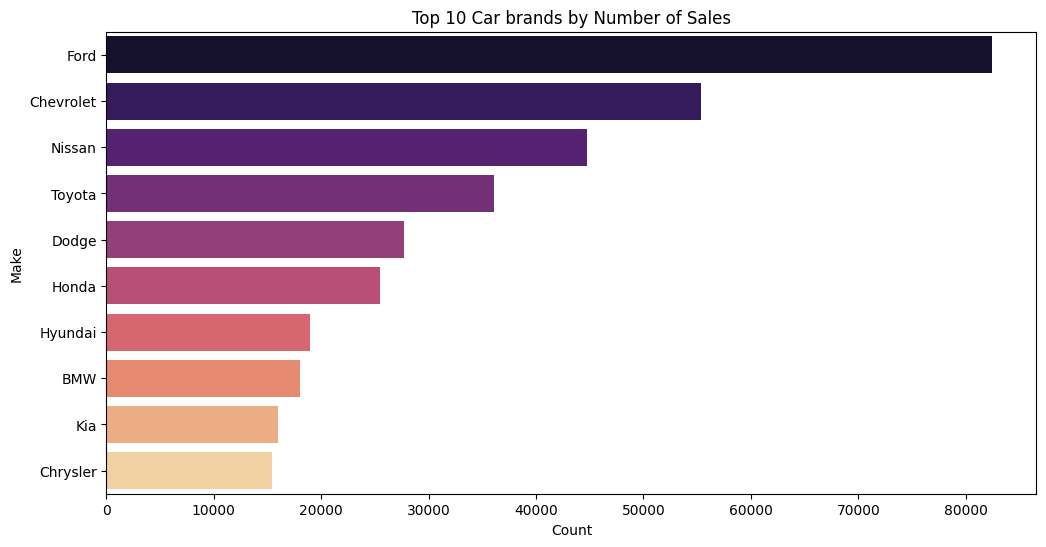

In [11]:
top_10_makes = df['make'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_makes.values, y=top_10_makes.index, palette='magma')
plt.title('Top 10 Car brands by Number of Sales')
plt.xlabel('Count')
plt.ylabel('Make')
plt.show()

C:\Users\bingi\AppData\Local\Temp\ipykernel_4712\1255724831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=brand_price.values, y=brand_price.index, palette='viridis')


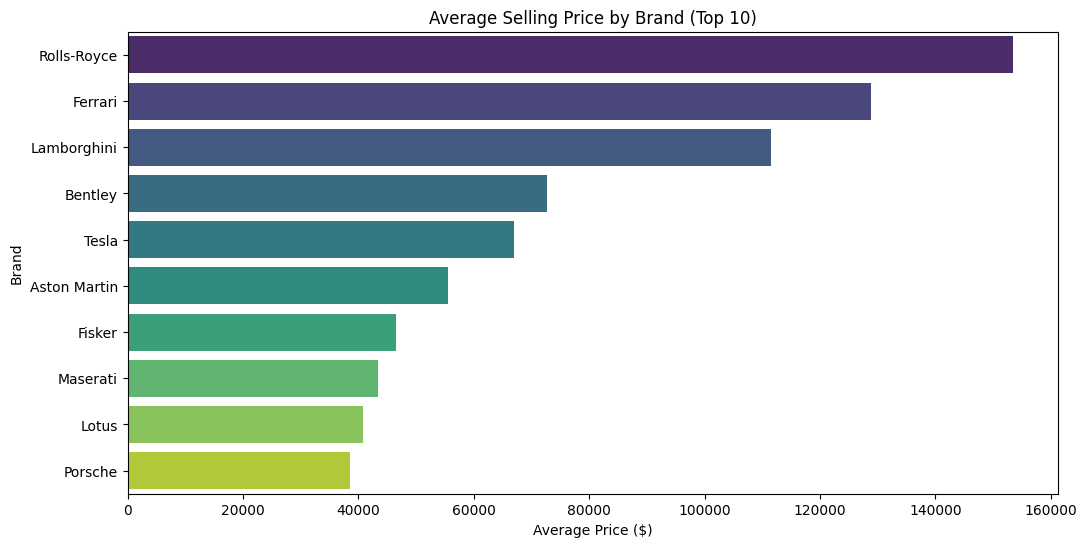

In [12]:
brand_price = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=brand_price.values, y=brand_price.index, palette='viridis')
plt.title('Average Selling Price by Brand (Top 10)')
plt.xlabel('Average Price ($)')
plt.ylabel('Brand')
plt.show()

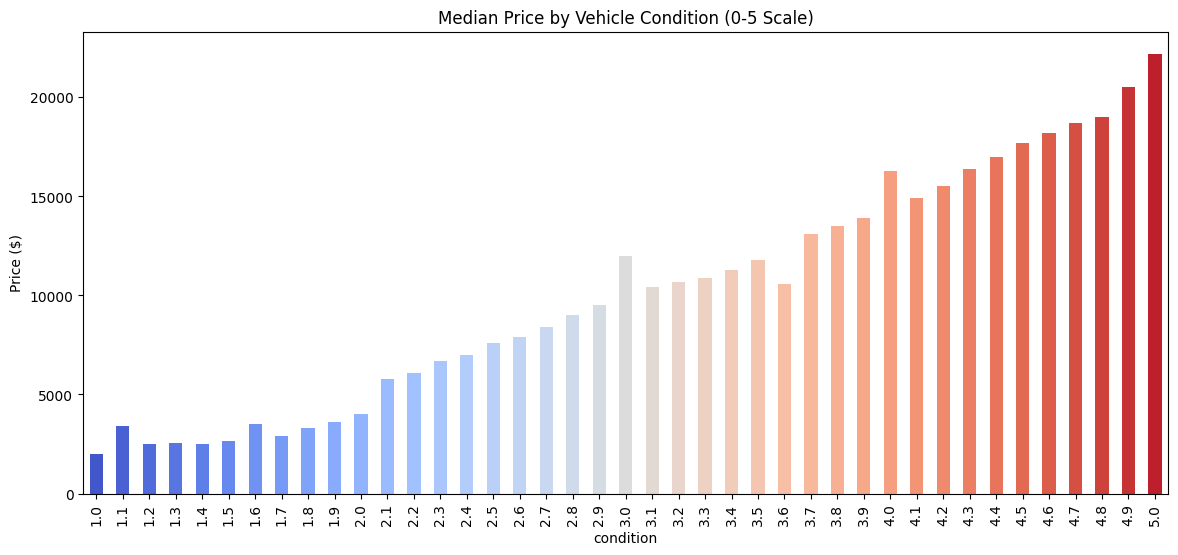

In [15]:
values = df.groupby('condition')['sellingprice'].median()
colors = sns.color_palette('coolwarm', n_colors=len(values))
plt.figure(figsize=(14, 6))
values.plot(kind='bar', color=colors)
plt.title('Median Price by Vehicle Condition (0-5 Scale)')
plt.ylabel('Price ($)')
plt.show()

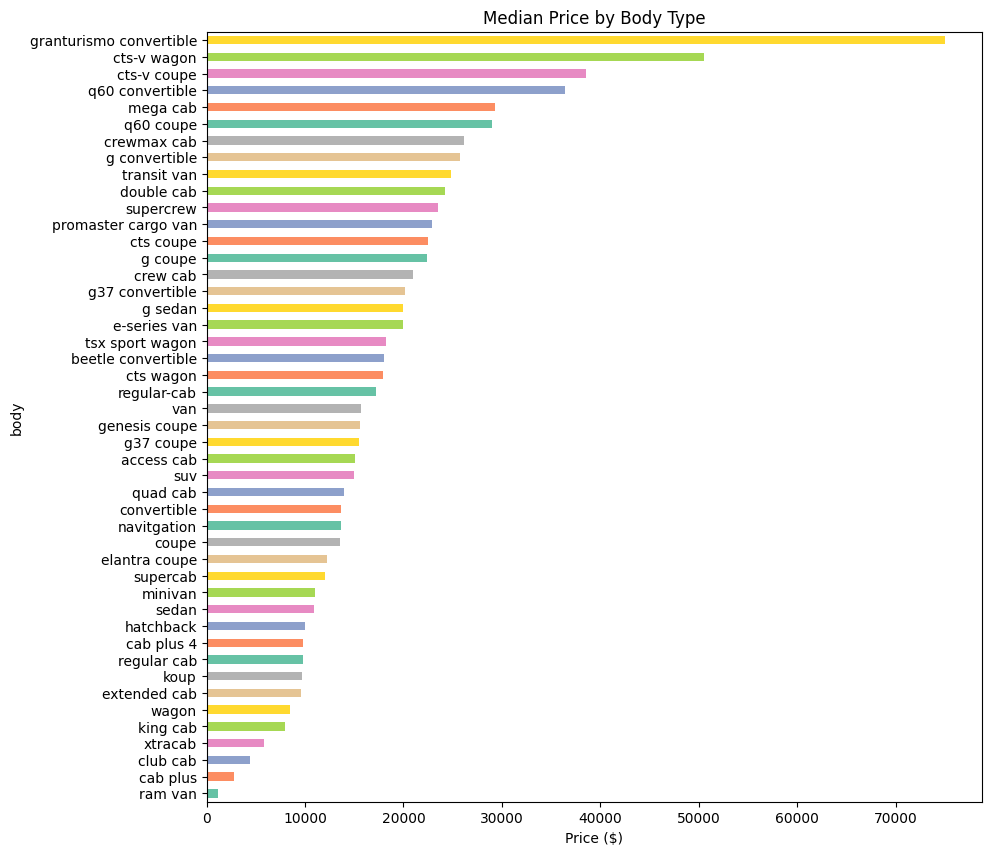

In [16]:
plt.figure(figsize=(10, 10))
unique_bodies = df['body'].unique()
colors = sns.color_palette('Set2', n_colors=len(unique_bodies))
df.groupby("body")["sellingprice"].median().sort_values().plot(kind="barh", color=colors)
plt.title("Median Price by Body Type")
plt.xlabel("Price ($)")
plt.show()

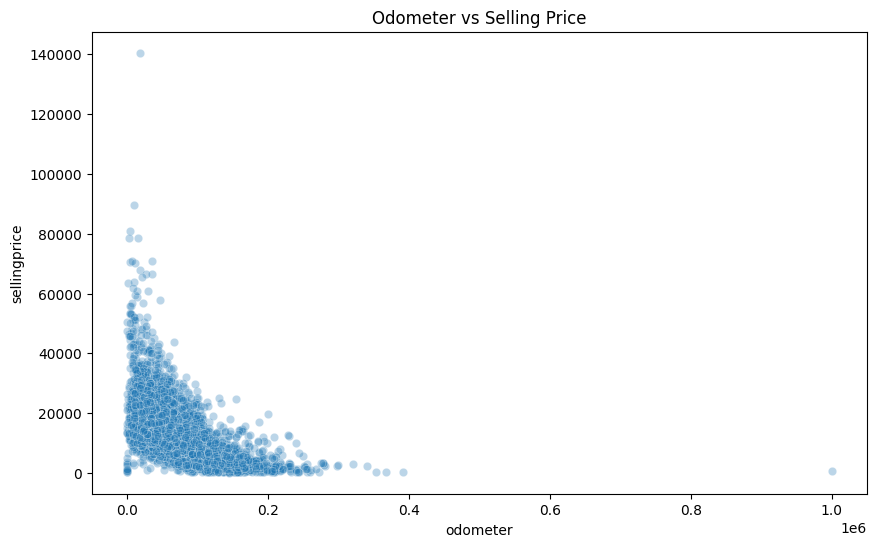

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(min(5000, len(df))), x='odometer', y='sellingprice', alpha=0.3)
plt.title('Odometer vs Selling Price')
plt.show()

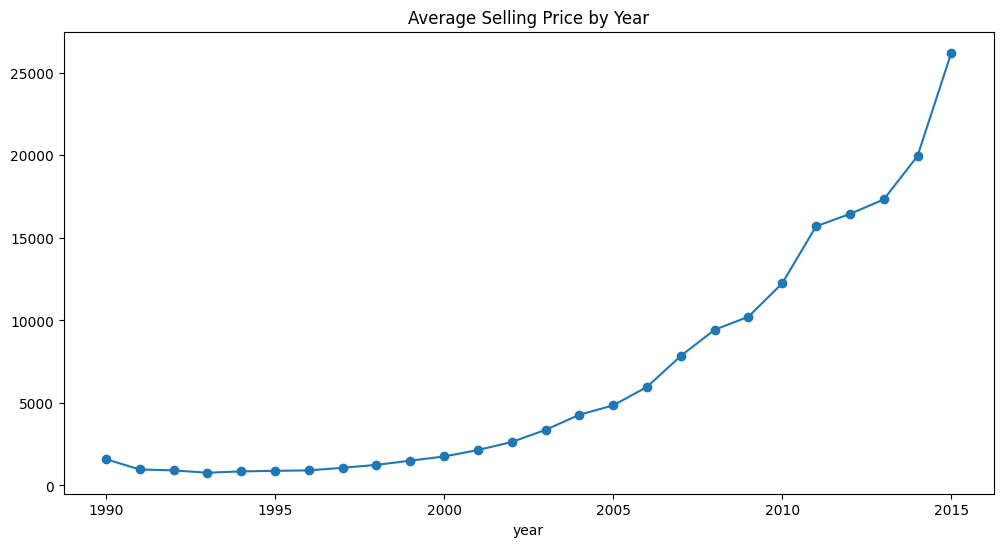

In [18]:
year_price = df.groupby('year')['sellingprice'].mean()
plt.figure(figsize=(12, 6))
year_price.plot(kind='line', marker='o')
plt.title('Average Selling Price by Year')
plt.show()

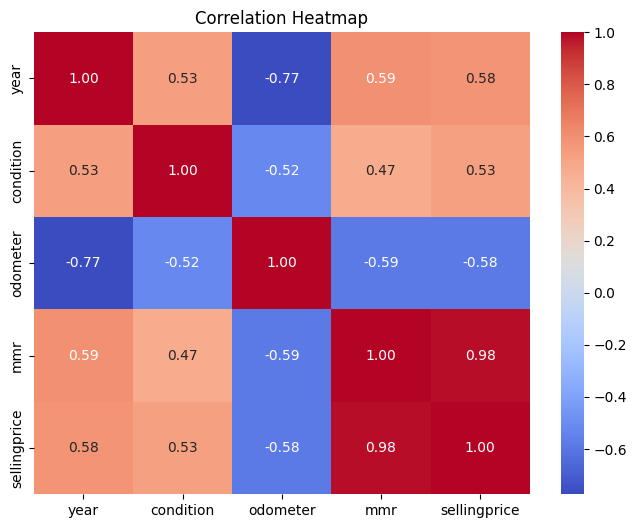

In [19]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()